# What is inside the MC ROOT files

A hands-on tour of the files everything else is built from. It answers, with plots rather
than prose: **which fields exist, what units they are in, and where they are not filled.**

Companion documents:
- [`doc/mc_provenance.md`](../../../doc/mc_provenance.md) — where these files come from
- [`doc/mc_binary_formats.md`](../../../doc/mc_binary_formats.md) — the upstream `.dat` / `.wout`
- [`doc/mc_energy_truth.md`](../../../doc/mc_energy_truth.md) — what the energy truth means

**Samples** live in `data_manager/data/mc_root_samples/` (one file per production, ~75 MB each,
copied from cluster62). They are gitignored; re-fetch with:

```bash
scp cluster62:/home3/ivkhar/Baikal/data/initial_data/MC_2020/nuatm/root/all/1000.root \
    data_manager/data/mc_root_samples/nuatm.root
```

**A limitation worth knowing up front:** uproot reads every scalar and per-track branch, but
*not* `fInteractions` — it is a `TClonesArray` of a custom class with no dictionary available.
Section 7 shows that chain from the `.npz` extracted on the cluster with PyROOT instead.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import uproot

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "data_manager").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
SAMPLES = ROOT_DIR / "data_manager/data/mc_root_samples"
NPZ = ROOT_DIR / "data_manager/data/mc_energy_truth_interactions"

PRODUCTIONS = ["nuatm", "nue2_100pev", "muatm"]
# validated categorical slots 1-3; colour identifies the production everywhere below
COLOR = {"nuatm": "#2a78d6", "nue2_100pev": "#eb6834", "muatm": "#1baf7a"}
INK, MUTED = "#1a1a19", "#6b6a63"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 9, "axes.titlesize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "axes.grid": True,
    "legend.frameon": False,
})

files = {p: uproot.open(SAMPLES / f"{p}.root") for p in PRODUCTIONS
         if (SAMPLES / f"{p}.root").exists()}
print("loaded:", ", ".join(files) or "nothing — see the scp command above")

loaded: nuatm, nue2_100pev, muatm


## 1. The file at a glance

Two trees: `Events` (one entry per event) and `ArrayConfig` (a single entry describing the
detector configuration and the generation settings). Note `Events;3` and `Events;2` — ROOT
cycles; reading `"Events"` gives the latest.

In [2]:
def leaf(tree, name, **kw):
    """Read a BMCEvent leaf by its short name, flattening per-track branches."""
    key = next(k for k in tree.keys() if k.endswith(name))
    a = tree[key].array(library="np", **kw)
    return np.concatenate([np.atleast_1d(x) for x in a]) if a.dtype == object else a


rows = []
for p, f in files.items():
    cfg = f["ArrayConfig"]
    g = lambda n: float(leaf(cfg, n)[0])
    n_ch = g("fChannelN")
    rows.append([p, f["Events"].num_entries, int(n_ch), int(g("fStringN")),
                 int(n_ch // 288), int(g("fDate")), int(g("fGeneration")),
                 f"{g('fMaxDistance') / 100:.0f} m"])

hdr = ["production", "events", "channels", "strings", "clusters", "date", "gen.model", "max dist"]
w = [max(len(str(r[i])) for r in rows + [hdr]) for i in range(len(hdr))]
print("  ".join(h.ljust(w[i]) for i, h in enumerate(hdr)))
print("  ".join("-" * w[i] for i in range(len(hdr))))
for r in rows:
    print("  ".join(str(v).ljust(w[i]) for i, v in enumerate(r)))
print("\ngeneration model: 4 = ReadFromExternalFile (air shower), 5 = NeutrinoGenerationInVolume")
print("max dist = radius of the generation volume; Reg energies below refer to entering it")

production   events  channels  strings  clusters  date    gen.model  max dist
-----------  ------  --------  -------  --------  ------  ---------  --------
nuatm        39547   2016      56       7         220119  5          250 m   
nue2_100pev  21523   2016      56       7         231018  5          250 m   
muatm        29749   2016      56       7         221109  4          250 m   

generation model: 4 = ReadFromExternalFile (air shower), 5 = NeutrinoGenerationInVolume
max dist = radius of the generation volume; Reg energies below refer to entering it


## 2. The branches, and what they mean

`BMCEvent` splits into event-level scalars, a per-track block (`fTracks.*`) and the detector
response (`fChannels.*`). The catalogue below is the short version of
`doc/mc_provenance.md` §5 — **units are given because the code comments cannot be trusted**
(section 3 demonstrates one such case).

In [3]:
t = files["nuatm"]["Events"]
short = sorted({k.split("/")[-1] for k in t.keys()
                if k.split("/")[-1].startswith("BMCEvent.") and k.count(".") <= 2})
print(f"{len(short)} BMCEvent branches; event-level ones:\n")
for k in short:
    if "fTracks" not in k and "fChannels" not in k and "BMCData" not in k:
        print("   ", k)

CATALOGUE = [
    ("fPrimaryParticleEnergy", "GeV", "energy of the primary (neutrino / cosmic-ray nucleus)"),
    ("fPrimaryParticleTheta/Phi", "deg", "direction of the primary"),
    ("fSumEnergyBundleSurf", "GeV", "bundle energy at the lake surface — muatm only"),
    ("fSumEnergyBundleReg", "GeV", "bundle energy entering the 250 m generation volume"),
    ("fX/fY/fZ (event)", "m", "shower axis — identically 0 for neutrino productions"),
    ("fRunN, fEventN", "-", "run / event id — both -1 for neutrino productions"),
    ("fEventWeight", "-", "1 for muatm, <1 for neutrino generation"),
    ("fTracks.fMuonEnergy", "GeV", "muon energy at the array plane; 3 cases, see section 4"),
    ("fTracks.fX/fY/fZ", "m", "reference point: closest approach to the detector centre"),
    ("fTracks.fTheta/fPhi", "deg", "direction of motion of the muon"),
    ("fTracks.fInteractions", "TeV", "stochastic losses (E,x,y,z), recorded above 0.1 GeV — unreadable by uproot"),
    ("fChannels.fPulses", "p.e./ns", "detector response: amplitude, time, fMagic origin flag"),
]
print("\n\nfield                       unit     meaning")
print("-" * 96)
for n, u, d in CATALOGUE:
    print(f"{n:27} {u:8} {d}")

22 BMCEvent branches; event-level ones:

    BMCEvent.
    BMCEvent.fEventN
    BMCEvent.fEventWeight
    BMCEvent.fExtensionWordCount
    BMCEvent.fFirstMuonTime
    BMCEvent.fHitChannelN
    BMCEvent.fMuonsN
    BMCEvent.fNucleonN
    BMCEvent.fPrimaryParticleEnergy
    BMCEvent.fPrimaryParticlePhi
    BMCEvent.fPrimaryParticleTheta
    BMCEvent.fResponseMuonsN
    BMCEvent.fRunN
    BMCEvent.fSumEnergyBundleReg
    BMCEvent.fSumEnergyBundleSurf
    BMCEvent.fTotalMuonsN
    BMCEvent.fX
    BMCEvent.fY
    BMCEvent.fZ


field                       unit     meaning
------------------------------------------------------------------------------------------------
fPrimaryParticleEnergy      GeV      energy of the primary (neutrino / cosmic-ray nucleus)
fPrimaryParticleTheta/Phi   deg      direction of the primary
fSumEnergyBundleSurf        GeV      bundle energy at the lake surface — muatm only
fSumEnergyBundleReg         GeV      bundle energy entering the 250 m generation volume
fX/fY

## 3. Primary energy — and how the unit was pinned down

The StreamerInfo in these very files annotates `fPrimaryParticleEnergy` as **TeV**/particle,
while the current `BMCEvent.h` says **GeV**/particle. The data settle it: the production named
`nu2.100PeV` must reach 100 PeV, and 100 PeV = 10⁸ GeV — which is exactly where its spectrum
ends. In TeV it would run to 100 EeV.

This matters beyond bookkeeping: `fSumEnergyBundleReg` shares a unit with this field (section 5),
so getting it wrong propagates.

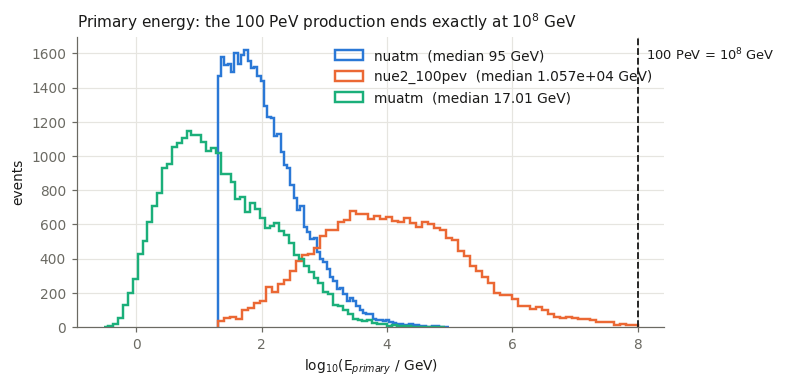

nuatm        min         20   median         95   max  9.676e+04  GeV
nue2_100pev  min      20.05   median  1.057e+04   max  9.943e+07  GeV
muatm        min     0.2998   median      17.01   max  8.547e+04  GeV


In [4]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))
for p, f in files.items():
    e = leaf(f["Events"], "fPrimaryParticleEnergy")
    ax.hist(np.log10(e[e > 0]), bins=70, histtype="step", lw=1.6,
            color=COLOR[p], label=f"{p}  (median {np.median(e):.4g} GeV)")
ax.axvline(8, color=INK, lw=1.2, ls="--")
ax.text(8, ax.get_ylim()[1] * 0.92, "  100 PeV = $10^8$ GeV", fontsize=8.5, color=INK)
ax.set_xlabel("log$_{10}$(E$_{primary}$ / GeV)")
ax.set_ylabel("events")
ax.set_title("Primary energy: the 100 PeV production ends exactly at $10^8$ GeV", loc="left")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

for p, f in files.items():
    e = leaf(f["Events"], "fPrimaryParticleEnergy")
    print(f"{p:12} min {e.min():10.4g}   median {np.median(e):10.4g}   max {e.max():10.4g}  GeV")

## 4. `fMuonEnergy` — one field, three meanings

This is the field an energy target would naively be built on, and it is the one most worth
understanding. It is the energy at the **reference point** — the closest approach of the track
to the centre of the whole detector — and its sign encodes *where the muon is* relative to
that point:

| value | meaning |
|---|---|
| positive | the muon is alive there; a real energy |
| exactly **−0.001** | sentinel: the muon is **born downstream** — it does not exist at that point |
| other negative | the muon **died upstream**; all its activity precedes the point |

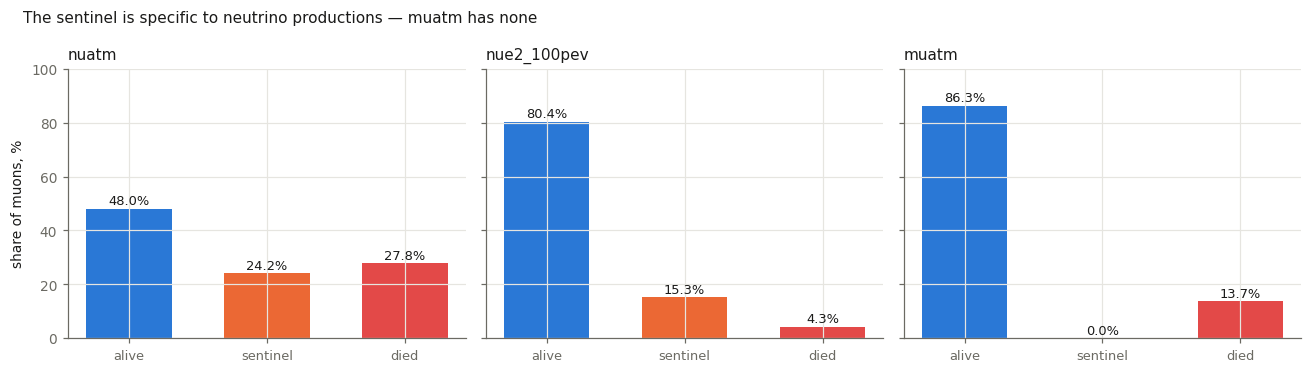

nuatm: the sentinel is exactly -0.001 in 9,568 tracks,
while the genuinely negative values form a smooth tail: -109.4 … -0.0080 GeV
-> the -0.001 is a placeholder, not a small negative energy


In [5]:
SENTINEL = np.float32(-0.001)
CLS_COLOR = ["#2a78d6", "#eb6834", "#e34948"]
CLS_NAME = ["alive (E > 0)", "sentinel (−0.001)", "died upstream"]

fig, axes = plt.subplots(1, len(files), figsize=(4.0 * len(files), 3.4), sharey=True)
for ax, (p, f) in zip(np.atleast_1d(axes), files.items()):
    e = leaf(f["Events"], "fTracks.fMuonEnergy")
    cls = np.where(e > 0, 0, np.where(e.astype(np.float32) == SENTINEL, 1, 2))
    frac = [100 * (cls == c).mean() for c in range(3)]
    ax.bar(range(3), frac, color=CLS_COLOR, width=0.62)
    for i, v in enumerate(frac):
        ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=8.5, color=INK)
    ax.set_xticks(range(3))
    ax.set_xticklabels(["alive", "sentinel", "died"], fontsize=8.5)
    ax.set_ylim(0, 100)
    ax.set_title(p, loc="left")
np.atleast_1d(axes)[0].set_ylabel("share of muons, %")
fig.suptitle("The sentinel is specific to neutrino productions — muatm has none",
             x=0.02, ha="left", fontsize=10)
plt.tight_layout()
plt.show()

e = leaf(files["nuatm"]["Events"], "fTracks.fMuonEnergy")
neg = e[(e < 0) & (e.astype(np.float32) != SENTINEL)]
print(f"nuatm: the sentinel is exactly -0.001 in {int((e.astype(np.float32) == SENTINEL).sum()):,} tracks,")
print(f"while the genuinely negative values form a smooth tail: {neg.min():.1f} … {neg.max():.4f} GeV")
print("-> the -0.001 is a placeholder, not a small negative energy")

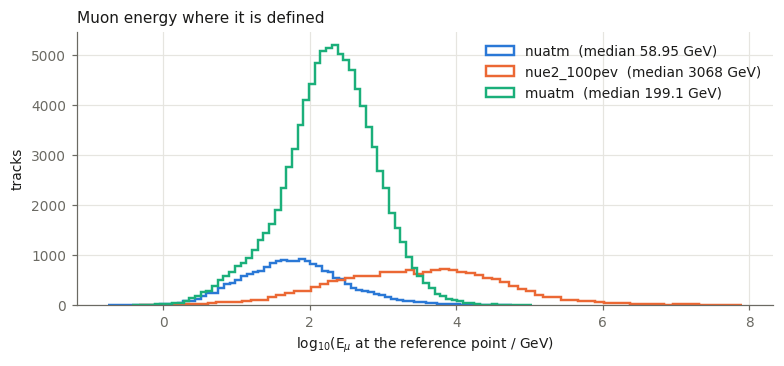

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))
for p, f in files.items():
    e = leaf(f["Events"], "fTracks.fMuonEnergy")
    e = e[e > 0]
    ax.hist(np.log10(e), bins=70, histtype="step", lw=1.6, color=COLOR[p],
            label=f"{p}  (median {np.median(e):.4g} GeV)")
ax.set_xlabel("log$_{10}$(E$_\\mu$ at the reference point / GeV)")
ax.set_ylabel("tracks")
ax.set_title("Muon energy where it is defined", loc="left")
ax.legend()
plt.tight_layout()
plt.show()

## 5. The two bundle energies

`fSumEnergyBundleSurf` and `fSumEnergyBundleReg` are the energies of the muon bundle at the
lake surface and on entering the 250 m generation volume. For neutrino productions the muon is
born under water, so *Surf* is meaningless and left at zero — while *Reg* is the only energy
defined for **100%** of tracks, sentinels included.

fraction of events where the field is exactly zero

production          Surf       Reg


nuatm             100.0%      0.0%
nue2_100pev       100.0%      0.0%
muatm               0.0%      0.0%


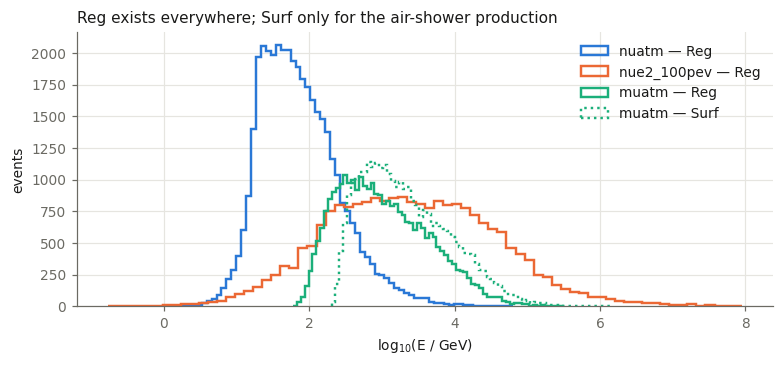

In [7]:
print("fraction of events where the field is exactly zero\n")
print(f"{'production':14}{'Surf':>10}{'Reg':>10}")
for p, f in files.items():
    s = leaf(f["Events"], "fSumEnergyBundleSurf")
    r = leaf(f["Events"], "fSumEnergyBundleReg")
    print(f"{p:14}{100 * (s == 0).mean():9.1f}%{100 * (r == 0).mean():9.1f}%")

fig, ax = plt.subplots(figsize=(7.2, 3.4))
for p, f in files.items():
    r = leaf(f["Events"], "fSumEnergyBundleReg")
    ax.hist(np.log10(r[r > 0]), bins=70, histtype="step", lw=1.6, color=COLOR[p], label=f"{p} — Reg")
    s = leaf(f["Events"], "fSumEnergyBundleSurf")
    if (s > 0).any():
        ax.hist(np.log10(s[s > 0]), bins=70, histtype="step", lw=1.6, ls=":",
                color=COLOR[p], label=f"{p} — Surf")
ax.set_xlabel("log$_{10}$(E / GeV)")
ax.set_ylabel("events")
ax.set_title("Reg exists everywhere; Surf only for the air-shower production", loc="left")
ax.legend()
plt.tight_layout()
plt.show()

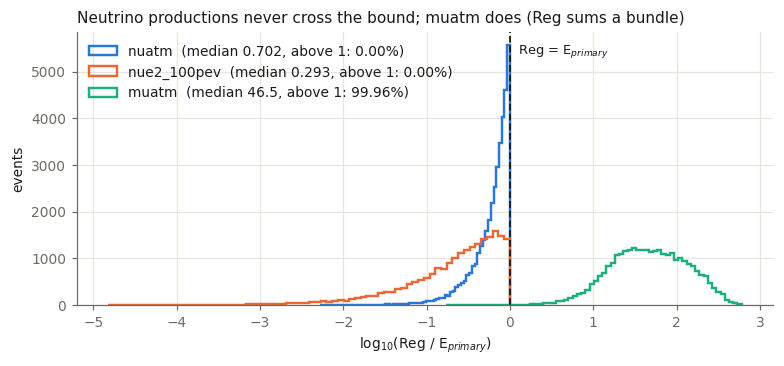

In [8]:
# The kinematic bound that proves Reg shares a unit with the primary energy:
# a muon cannot carry more than the neutrino brought.
fig, ax = plt.subplots(figsize=(7.2, 3.4))
for p, f in files.items():
    r = leaf(f["Events"], "fSumEnergyBundleReg")
    e = leaf(f["Events"], "fPrimaryParticleEnergy")
    ratio = r / e
    ax.hist(np.log10(ratio[ratio > 0]), bins=70, histtype="step", lw=1.6, color=COLOR[p],
            label=f"{p}  (median {np.median(ratio):.3g}, above 1: {100 * (ratio > 1).mean():.2f}%)")
ax.axvline(0, color=INK, lw=1.2, ls="--")
ax.text(0, ax.get_ylim()[1] * 0.92, "  Reg = E$_{primary}$", fontsize=8.5, color=INK)
ax.set_xlabel("log$_{10}$(Reg / E$_{primary}$)")
ax.set_ylabel("events")
ax.set_title("Neutrino productions never cross the bound; muatm does (Reg sums a bundle)",
             loc="left")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 6. Fields that look useful and are not

Three traps that cost real time. Each is a field that exists, reads without error, and is
simply not filled for the productions we use.

In [9]:
print(f"{'production':14}{'run':>10}{'event':>10}{'vertex |r|':>13}{'weight':>10}")
print("-" * 57)
for p, f in files.items():
    tr = f["Events"]
    run, ev = leaf(tr, "fRunN"), leaf(tr, "fEventN")
    vx, vy, vz = (leaf(tr, f"BMCEvent.f{c}") for c in "XYZ")
    w = leaf(tr, "fEventWeight")
    r = np.sqrt(vx ** 2 + vy ** 2 + vz ** 2)
    print(f"{p:14}{np.median(run):10.0f}{np.median(ev):10.0f}"
          f"{np.median(r):12.1f} m{np.median(w):10.3f}")

print("\n-> for neutrino productions run/event are -1 and the vertex is (0,0,0):")
print("   there is no intrinsic event id, so matching against upstream files uses a")
print("   content fingerprint (theta, phi, E_primary, t_first_muon, Reg, weight).")
print("   See doc/mc_provenance.md section 4 — it is unique for 1,000,000/1,000,000 events.")

production           run     event   vertex |r|    weight
---------------------------------------------------------
nuatm                 -1        -1         0.0 m     0.413
nue2_100pev           -1        -1         0.0 m     2.211
muatm             211285  15082820       264.6 m     1.000

-> for neutrino productions run/event are -1 and the vertex is (0,0,0):
   there is no intrinsic event id, so matching against upstream files uses a
   content fingerprint (theta, phi, E_primary, t_first_muon, Reg, weight).
   See doc/mc_provenance.md section 4 — it is unique for 1,000,000/1,000,000 events.


## 7. The interaction chain — what uproot cannot reach

`fInteractions` holds the stochastic energy losses that make an energy target possible at all.
uproot cannot deserialise it (an unsplit `TClonesArray` of a custom class), so the extraction
runs on the cluster with PyROOT via `TTree::Draw` — see `extract_interactions.py`. The cell
below first shows the failure, then the same data from the extracted `.npz`.

In [10]:
try:
    files["nuatm"]["Events"]["BMCEvent.fTracks.fInteractions"].array(entry_stop=2)
    print("unexpectedly readable")
except Exception as exc:
    print(f"{type(exc).__name__}: {str(exc).splitlines()[0]}")

npz_file = next(iter(sorted((NPZ / "nuatm").glob("*.npz"))), None)
if npz_file is None:
    print("\nno .npz available locally — skipping the rest of this section")
else:
    d = np.load(npz_file)
    print(f"\n{npz_file.name}: {len(d['trk_energy']):,} tracks, {len(d['int_energy']):,} interactions")
    print("keys:", ", ".join(d.files))

ValueError: cannot produce Awkward Arrays for interpretation AsObjects(AsArray(False, False, Model_TClonesArray, ())) because

1000.npz: 39,547 tracks, 36,710 interactions
keys: n_resp_mu, run_n, event_n, trk_theta, trk_phi, trk_x, trk_y, trk_z, trk_energy, trk_n_inter, int_x, int_y, int_z, int_energy, int_block, n_tracks, n_events, start_index


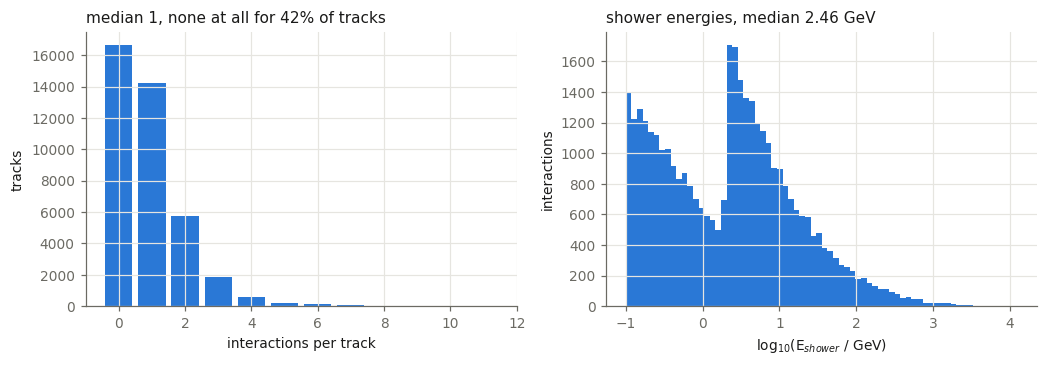

Minimum shower energy: 0.1 GeV — the generator's recording threshold,
so the softest losses are folded into the continuous term, not listed individually.
Stored in TeV while fMuonEnergy is in GeV — mixed units inside one record.
This chain is what E_dep / L_path are built from, and it needs no fMuonEnergy,
which is why those targets stay defined even for sentinel tracks.


In [11]:
if npz_file is not None:
    n_int = d["trk_n_inter"]
    e_int = d["int_energy"]                    # already GeV: the extractor converts from TeV
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.6, 3.4))

    edges = np.arange(0, 13) - 0.5
    a1.hist(np.clip(n_int, 0, 12), bins=edges, color=COLOR["nuatm"], rwidth=0.82)
    a1.set_xlabel("interactions per track")
    a1.set_ylabel("tracks")
    a1.set_title(f"median {np.median(n_int):.0f}, none at all for "
                 f"{100 * (n_int == 0).mean():.0f}% of tracks", loc="left")

    pos = e_int[e_int > 0]
    a2.hist(np.log10(pos), bins=70, color=COLOR["nuatm"])
    a2.set_xlabel("log$_{10}$(E$_{shower}$ / GeV)")
    a2.set_ylabel("interactions")
    a2.set_title(f"shower energies, median {np.median(pos):.3g} GeV", loc="left")
    plt.tight_layout()
    plt.show()

    print(f"Minimum shower energy: {pos.min():.3g} GeV — the generator's recording threshold,")
    print("so the softest losses are folded into the continuous term, not listed individually.")
    print("Stored in TeV while fMuonEnergy is in GeV — mixed units inside one record.")
    print("This chain is what E_dep / L_path are built from, and it needs no fMuonEnergy,")
    print("which is why those targets stay defined even for sentinel tracks.")

## 9. Where is the boundary of the registration volume?

`fSumEnergyBundleReg` is the energy on entering some volume, but its geometry is not
established. This section locates it directly: walk backwards along each track from the
reference point, adding losses back, until the energy reaches `Reg`. The cloud of such points
over many muons should draw the boundary.

**The loss model is the one `energy.C` uses**, and nothing else:

```
E(s) = E_ref + 0.24 · |s| + Σ (recorded showers between s and 0),   s < 0
```

Ionisation plus the *actual* stochastic losses from the file. No `b·E` term: that is the
population mean of exactly the processes already listed shower by shower, so adding it would
double-count. Where the chain runs out, the walk continues on ionisation alone.

Sentinel tracks are excluded — for them `E_ref` does not exist.

In [12]:
IONISATION = 0.24     # GeV/m, the value used by energy.C

tree = files["nuatm"]["Events"]
e_ref = leaf(tree, "fTracks.fMuonEnergy")
e_reg = leaf(tree, "fSumEnergyBundleReg")
th, ph = np.radians(leaf(tree, "fTracks.fTheta")), np.radians(leaf(tree, "fTracks.fPhi"))
x, y, z = (leaf(tree, f"fTracks.f{c}") for c in "XYZ")
direction = np.stack([np.sin(th) * np.cos(ph), np.sin(th) * np.sin(ph), np.cos(th)], axis=1)
ref = np.stack([x, y, z], axis=1)

alive = e_ref > 0
print(f"{alive.sum():,} muons alive at the reference point "
      f"({100 * (~alive).mean():.1f}% excluded: sentinels and died-upstream)")

# shower chain from the .npz (uproot cannot read fInteractions, section 7).
# nuatm has one muon per event, so npz track i corresponds to ROOT entry i.
off = np.concatenate([[0], np.cumsum(d["trk_n_inter"])]).astype(int)
th_n, ph_n = np.radians(d["trk_theta"]), np.radians(d["trk_phi"])
dir_npz = np.stack([np.sin(th_n) * np.cos(ph_n), np.sin(th_n) * np.sin(ph_n),
                    np.cos(th_n)], axis=1)
ref_npz = np.stack([d["trk_x"], d["trk_y"], d["trk_z"]], axis=1)
pts = np.stack([d["int_x"], d["int_y"], d["int_z"]], axis=1)
e_shower_all = d["int_energy"]            # GeV already


def walk_back(i):
    """Signed position (<=0) where the energy going backwards reaches Reg."""
    a, b = off[i], off[i + 1]
    if b > a:
        s_sh = (pts[a:b] - ref_npz[i]) @ dir_npz[i]
        e_sh = e_shower_all[a:b]
        order = np.argsort(s_sh)[::-1]
        s_sh, e_sh = s_sh[order], e_sh[order]
    else:
        s_sh, e_sh = np.zeros(0), np.zeros(0)
    energy, s_prev, used = e_ref[i], 0.0, False
    for s_i, e_i in zip(s_sh, e_sh):
        if s_i > 0:
            continue
        reached = energy + IONISATION * (s_prev - s_i)
        if reached >= e_reg[i]:
            return s_prev - (e_reg[i] - energy) / IONISATION, True
        energy, s_prev, used = reached + e_i, s_i, True
    return s_prev - (e_reg[i] - energy) / IONISATION, used


idx = np.where(alive)[0]
out = [walk_back(i) for i in idx]
s_star = np.array([o[0] for o in out])
dist = -s_star
entry = ref[idx] + s_star[:, None] * direction[idx]
R = np.linalg.norm(entry, axis=1)
print(f"distance walked back, m: " +
      "  ".join(f"p{q}={np.percentile(dist, q):,.0f}" for q in (5, 25, 50, 75, 95, 99)))

18,997 muons alive at the reference point (52.0% excluded: sentinels and died-upstream)
distance walked back, m: p5=16  p25=85  p50=235  p75=540  p95=1,039  p99=2,302


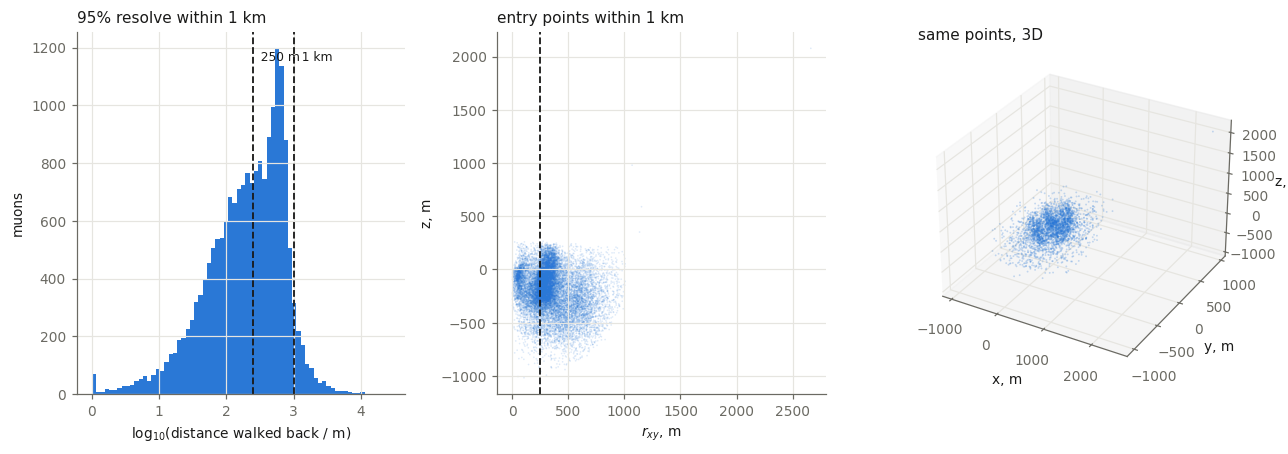

|r|   (within 1 km): p5   129  median   382  p95    819 m
r_xy  (within 1 km): p5    69  median   315  p95    699 m
|z|   (within 1 km): p5    16  median   182  p95    562 m

of those, inside r = 250 m: 13.9%


In [13]:
NEAR = 1000     # m; beyond this an ionisation-only walk is not credible
near = dist < NEAR

fig = plt.figure(figsize=(11.5, 4.2))
ax1 = fig.add_subplot(1, 3, 1)
ax1.hist(np.log10(np.clip(dist, 1, None)), bins=70, color=COLOR["nuatm"])
for v, lab in [(250, "250 m"), (NEAR, "1 km")]:
    ax1.axvline(np.log10(v), color=INK, lw=1.2, ls="--")
    ax1.text(np.log10(v), ax1.get_ylim()[1] * 0.92, f"  {lab}", fontsize=8, color=INK)
ax1.set_xlabel("log$_{10}$(distance walked back / m)"); ax1.set_ylabel("muons")
ax1.set_title(f"{100 * near.mean():.0f}% resolve within 1 km", loc="left")

ax2 = fig.add_subplot(1, 3, 2)
ax2.scatter(np.hypot(entry[near, 0], entry[near, 1]), entry[near, 2],
            s=1.2, alpha=0.15, color=COLOR["nuatm"], edgecolors="none")
ax2.axvline(250, color=INK, lw=1.2, ls="--")
ax2.set_xlabel("$r_{xy}$, m"); ax2.set_ylabel("z, m")
ax2.set_title("entry points within 1 km", loc="left")

ax3 = fig.add_subplot(1, 3, 3, projection="3d")
sub = np.random.default_rng(0).choice(np.where(near)[0],
                                      size=min(3000, int(near.sum())), replace=False)
ax3.scatter(entry[sub, 0], entry[sub, 1], entry[sub, 2], s=1.5, alpha=0.25,
            color=COLOR["nuatm"], edgecolors="none")
ax3.set_xlabel("x, m"); ax3.set_ylabel("y, m"); ax3.set_zlabel("z, m")
ax3.set_title("same points, 3D", loc="left")
plt.tight_layout(); plt.show()

for name, v in [("|r|", R[near]), ("r_xy", np.hypot(entry[near, 0], entry[near, 1])),
                ("|z|", np.abs(entry[near, 2]))]:
    print(f"{name:5} (within 1 km): p5 {np.percentile(v, 5):5.0f}  median {np.median(v):5.0f}  "
          f"p95 {np.percentile(v, 95):6.0f} m")
print(f"\nof those, inside r = 250 m: {100 * np.mean(R[near] < 250):.1f}%")

### Distribution of the distance back to `E = Reg`

The quantity itself, in detail: how far back along the track one has to walk from the reference
point (`s = 0`) before the muon's energy reaches `Reg`. Propagation is the fullest the data
allow — ionisation at 0.24 GeV/m **plus every recorded shower** passed on the way (threshold
0.1 GeV), i.e. exactly the `energy.C` model.

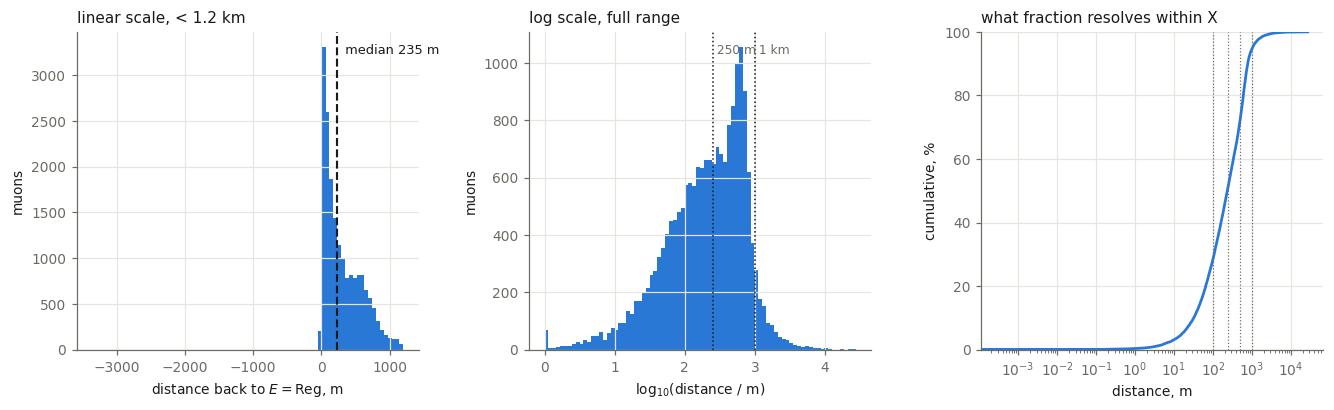

distance back to E = Reg, m
   p1  =       3.4
   p5  =      16.2
   p10 =      32.4
   p25 =      84.9
   p50 =     235.0
   p75 =     539.8
   p90 =     784.5
   p95 =   1,038.5
   p99 =   2,302.5
   mean = 384.2   max = 27,244

   within   100 m:  28.2%
   within   250 m:  51.7%
   within   500 m:  72.2%
   within  1000 m:  94.5%
   within  2000 m:  98.7%

negative (Reg < E_ref, impossible): 5 of 18,997


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12.2, 3.8))

# (a) linear, the bulk
a = axes[0]
a.hist(dist[dist < 1200], bins=80, color=COLOR["nuatm"])
for v, c in [(np.median(dist), INK)]:
    a.axvline(v, color=c, lw=1.4, ls="--")
    a.text(v, a.get_ylim()[1] * 0.93, f"  median {v:.0f} m", fontsize=8.5, color=c)
a.set_xlabel("distance back to $E = $Reg, m"); a.set_ylabel("muons")
a.set_title("linear scale, < 1.2 km", loc="left")

# (b) log, everything
b = axes[1]
b.hist(np.log10(np.clip(dist, 1, None)), bins=80, color=COLOR["nuatm"])
for v, lab in [(250, "250 m"), (1000, "1 km")]:
    b.axvline(np.log10(v), color=INK, lw=1.0, ls=":")
    b.text(np.log10(v), b.get_ylim()[1] * 0.93, f" {lab}", fontsize=8, color=MUTED)
b.set_xlabel("log$_{10}$(distance / m)"); b.set_ylabel("muons")
b.set_title("log scale, full range", loc="left")

# (c) cumulative
c = axes[2]
srt = np.sort(dist)
c.plot(srt, 100 * np.arange(1, len(srt) + 1) / len(srt), color=COLOR["nuatm"], lw=1.8)
c.set_xscale("log")
for v in (100, 250, 500, 1000):
    c.axvline(v, color=MUTED, lw=0.8, ls=":")
c.set_xlabel("distance, m"); c.set_ylabel("cumulative, %")
c.set_title("what fraction resolves within X", loc="left")
c.set_ylim(0, 100)
plt.tight_layout()
plt.show()

print("distance back to E = Reg, m")
for q in (1, 5, 10, 25, 50, 75, 90, 95, 99):
    print(f"   p{q:<2} = {np.percentile(dist, q):9,.1f}")
print(f"   mean = {dist.mean():,.1f}   max = {dist.max():,.0f}")
print()
for v in (100, 250, 500, 1000, 2000):
    print(f"   within {v:>5} m: {100 * np.mean(dist < v):5.1f}%")
print(f"\nnegative (Reg < E_ref, impossible): {int((dist < 0).sum())} of {len(dist):,}")

### What this shows

No sharp surface: a sphere would pile `|r|` onto a spike, a cylinder would fill a rectangle
with clean edges. The points fill a diffuse region — consistent with `Reg` being the energy at
the muon's *birth* for events whose neutrino interacted nearby, mixed with true entry points
for muons born further out.

There is also a long tail where the walk runs kilometres. Ionisation alone cannot recover such
energy differences over any plausible distance, so for those tracks the radiative losses
happened outside the region where showers are recorded (±400 m, section 7).

## 10. What exactly is `Reg`? A geometric hypothesis, drawn out

The generator's `steer.dat` states:

```
maximum distance from muon upon PMT where there is registration probob.(cm): 2.5e4
minimal limit for catastrophic losses (GeV): 0.10
```

So the 25000 in `fMaxDistance` is **250 m from the muon to a PMT** — a cut on the response
calculation, not a radius around the detector. (The second line independently confirms the
0.1 GeV shower threshold measured in section 7.)

Hypothesis: `Reg` is the muon's energy when it first comes within 250 m of the array, i.e. `L`
metres before the reference point with `L` fixed by geometry. The panels draw that for single
events, then test it on the full sample.

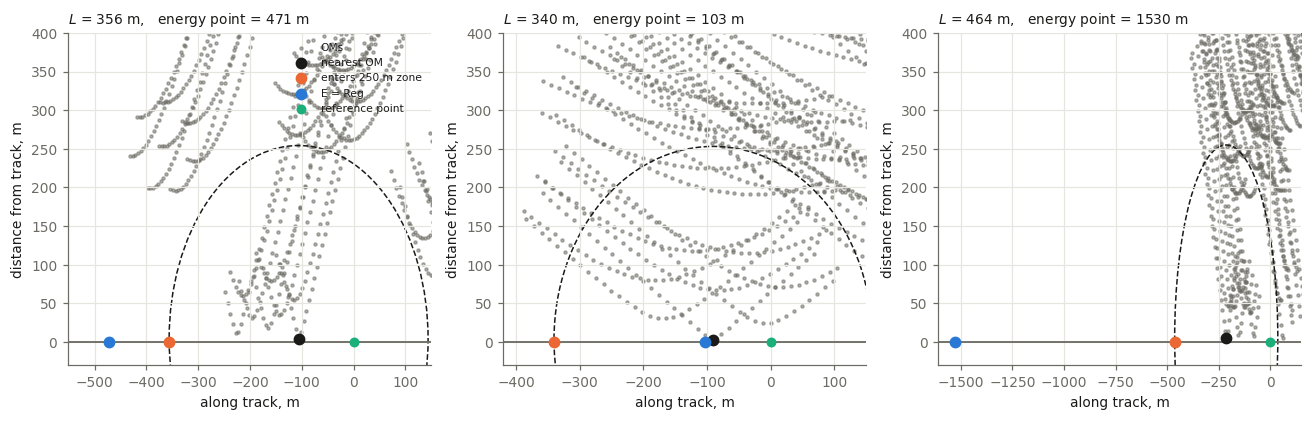

In [15]:
cfg = files["nuatm"]["ArrayConfig"]
om = np.stack([leaf(cfg, f"fChannels.f{c}") / 100.0 for c in "XYZ"], axis=1)
RMAX = 250.0


def geometry(i):
    """Entry into the 250 m zone of the OM closest to the track."""
    v = om - ref[i]
    pr = v @ direction[i]
    perp2 = np.maximum((v ** 2).sum(1) - pr ** 2, 0)
    j = int(np.argmin(perp2))
    return pr[j] - np.sqrt(max(RMAX ** 2 - perp2[j], 0)), j


fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
for ax, i in zip(axes, idx[[3, 17, 42]]):
    s_in, j = geometry(i)
    s_en = -(e_reg[i] - e_ref[i]) / IONISATION

    def to2d(p):
        w = np.atleast_2d(p) - ref[i]
        along = w @ direction[i]
        return along, np.linalg.norm(w - along[:, None] * direction[i], axis=1)

    a_om, r_om = to2d(om)
    keep = np.abs(a_om - a_om[j]) < 800
    ax.axhline(0, color=MUTED, lw=1.2)
    ax.scatter(a_om[keep], r_om[keep], s=4, color=MUTED, alpha=0.5, label="OMs")
    ax.scatter(a_om[j], r_om[j], s=45, color=INK, zorder=5, label="nearest OM")
    ax.add_patch(plt.Circle((a_om[j], r_om[j]), RMAX, fill=False, color=INK, ls="--", lw=1.0))
    ax.scatter([s_in], [0], s=45, color="#eb6834", zorder=6, label="enters 250 m zone")
    ax.scatter([s_en], [0], s=45, color="#2a78d6", zorder=6, label="E = Reg")
    ax.scatter([0], [0], s=30, color="#1baf7a", zorder=6, label="reference point")
    ax.set_xlim(min(s_in, s_en) - 80, 150)
    ax.set_ylim(-30, 400)
    ax.set_xlabel("along track, m"); ax.set_ylabel("distance from track, m")
    ax.set_title(f"$L$ = {-s_in:.0f} m,   energy point = {-s_en:.0f} m", loc="left", fontsize=9)
axes[0].legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

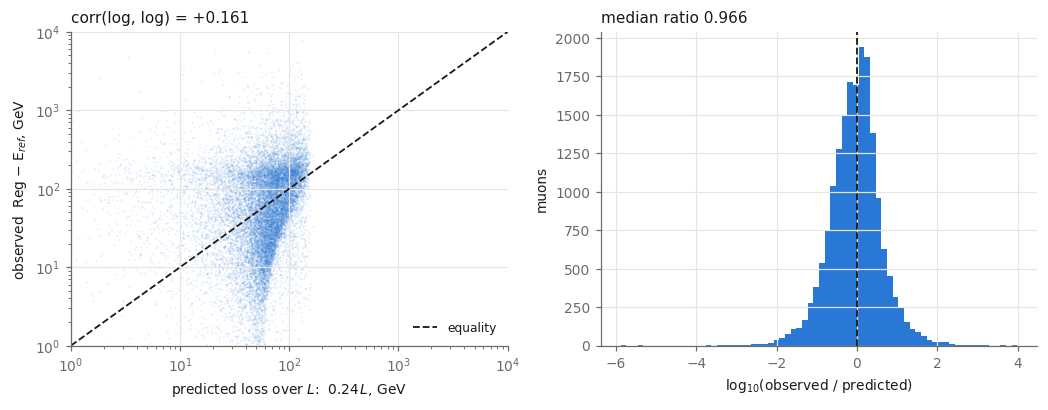

L, m        : median  252.0  p5   6.7  p95  506.1
Reg - E_ref : median   61.3 GeV
0.24 * L    : median   60.5 GeV


In [16]:
L = np.array([-geometry(i)[0] for i in idx])
dE = e_reg[idx] - e_ref[idx]
pred = L * IONISATION
ok = (pred > 0) & (dE > 0)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(9.6, 3.8))
a1.scatter(pred[ok], dE[ok], s=1.5, alpha=0.12, color=COLOR["nuatm"], edgecolors="none")
lim = [1, 1e4]
a1.plot(lim, lim, color=INK, lw=1.2, ls="--", label="equality")
a1.set_xscale("log"); a1.set_yscale("log"); a1.set_xlim(lim); a1.set_ylim(lim)
a1.set_xlabel("predicted loss over $L$:  0.24$\\,L$, GeV")
a1.set_ylabel("observed  Reg $-$ E$_{ref}$, GeV")
a1.set_title(f"corr(log, log) = {np.corrcoef(np.log(pred[ok]), np.log(dE[ok]))[0, 1]:+.3f}",
             loc="left")
a1.legend(fontsize=8)

a2.hist(np.log10(dE[ok] / pred[ok]), bins=70, color=COLOR["nuatm"])
a2.axvline(0, color=INK, lw=1.2, ls="--")
a2.set_xlabel("log$_{10}$(observed / predicted)"); a2.set_ylabel("muons")
a2.set_title(f"median ratio {np.median(dE[ok] / pred[ok]):.3f}", loc="left")
plt.tight_layout(); plt.show()

print(f"L, m        : median {np.median(L):6.1f}  p5 {np.percentile(L, 5):5.1f}  p95 {np.percentile(L, 95):6.1f}")
print(f"Reg - E_ref : median {np.median(dE):6.1f} GeV")
print(f"0.24 * L    : median {np.median(pred):6.1f} GeV")

### Verdict

The medians line up almost perfectly — `0.24·L` = 62 GeV against an observed `Reg − E_ref` of
60 GeV, a ratio of 0.97 — **and that is the trap**. `L` spans two orders of magnitude across
the sample, so if `Reg` were the energy at that entry point, the two would track each other
event by event. They do not: the correlation is ~0.16, and the ratio histogram is a broad blob
spanning two decades instead of a spike at zero.

This is the third hypothesis to die this way here, after "energy lost inside a volume of radius
R" (medians matched at R = 200 m, correlation 0.11) and the 250 m sphere. **Matching medians
is cheap** — with one free length it can always be arranged. Only a per-event relation counts.

What the generator config *did* settle: `fMaxDistance` is a 250 m muon-to-PMT cut on the
response calculation, not a volume, and the shower threshold is 0.1 GeV. Both are now verified
externally. The meaning of `fSumEnergyBundleReg` itself remains open: it behaves like the
muon's energy somewhere upstream (median `Reg/E_ref` = 1.84, `corr(log Reg, log E_ref)` = 0.87),
and no geometric reading tested here reproduces it.

## 11. Interactive view

The entry-point cloud alone, rotatable, with the seven clusters drawn from the real channel
geometry in `ArrayConfig`. Drag to rotate; `%matplotlib widget` is an equivalent invocation if
`ipympl` is unavailable.

7 clusters: radius 61 m, height 527 m


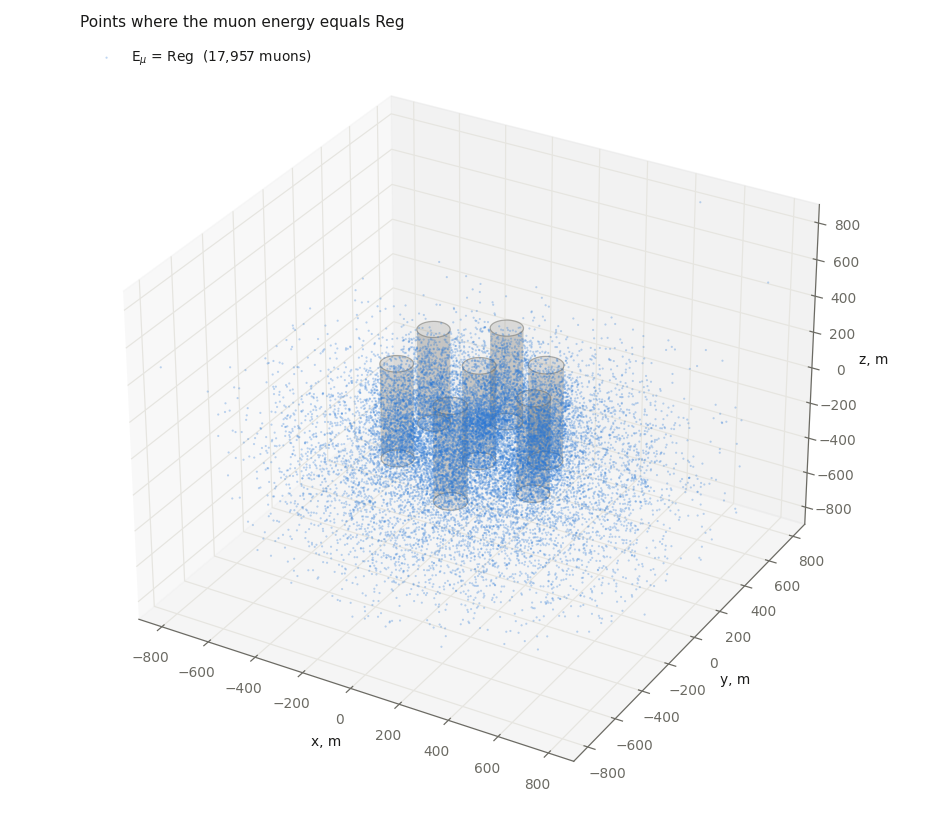

In [17]:
%matplotlib ipympl

geom = []
cluster_of_channel = np.arange(len(om)) // 288
for k in np.unique(cluster_of_channel):
    m = cluster_of_channel == k
    cx, cy = om[m, 0].mean(), om[m, 1].mean()
    geom.append(dict(x=cx, y=cy, r=np.hypot(om[m, 0] - cx, om[m, 1] - cy).max(),
                     z0=om[m, 2].min(), z1=om[m, 2].max()))
print(f"{len(geom)} clusters: radius {np.mean([g['r'] for g in geom]):.0f} m, "
      f"height {np.mean([g['z1'] - g['z0'] for g in geom]):.0f} m")

fig = plt.figure(figsize=(8.5, 7.5))
ax = fig.add_subplot(projection="3d")
theta = np.linspace(0, 2 * np.pi, 48)
for g in geom:
    zz = np.array([g["z0"], g["z1"]])
    T, Z = np.meshgrid(theta, zz)
    ax.plot_surface(g["x"] + g["r"] * np.cos(T), g["y"] + g["r"] * np.sin(T), Z,
                    color=MUTED, alpha=0.18, linewidth=0, shade=False)
    for zc in zz:
        ax.plot(g["x"] + g["r"] * np.cos(theta), g["y"] + g["r"] * np.sin(theta),
                np.full_like(theta, zc), color=MUTED, lw=0.8, alpha=0.5)

ax.scatter(entry[near, 0], entry[near, 1], entry[near, 2], s=2, alpha=0.30,
           color=COLOR["nuatm"], edgecolors="none",
           label=f"E$_\\mu$ = Reg  ({int(near.sum()):,} muons)")
lim = 900
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
ax.set_xlabel("x, m"); ax.set_ylabel("y, m"); ax.set_zlabel("z, m")
ax.set_title("Points where the muon energy equals Reg", loc="left")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

## 12. Summary

| | nuatm | nue2_100pev | muatm |
|---|---|---|---|
| primary | atmospheric ν | astrophysical ν$_\mu$, E$^{-2}$ | cosmic-ray nucleus |
| generation model | 5 (in volume) | 5 (in volume) | 4 (external file) |
| muons per event | 1 | 1 | bundle |
| `fMuonEnergy` usable | ~48% | ~82% | ~87% |
| `Surf` filled | no | no | yes |
| run / event id | −1 | −1 | filled |

**Units** (the comments disagree with the data, so these were established against external
anchors): `fPrimaryParticleEnergy`, `fMuonEnergy`, `fSumEnergyBundle*` are **GeV**;
`fInteractions.fEnergy` is **TeV**; event-record coordinates are metres, configuration-record
coordinates centimetres. Shower recording threshold: **0.1 GeV**.

**For targets.** Anything propagated from `fMuonEnergy` inherits its holes — unusable for ~52%
of nuatm — and, as sections 9–10 show, is mostly extrapolation beyond the recorded chain.
`E_dep` and `L_path` are built from the chain plus ionisation, need no `fMuonEnergy`, and stay
defined for every track. Reasoning: [`doc/mc_energy_truth.md`](../../../doc/mc_energy_truth.md);
claim-by-claim status: [`doc/claims_log.md`](../../../doc/claims_log.md).